# Diasense — CGM Multi-Task LSTM (Full Pipeline)

**Goal:** Use Dexcom G6 blood glucose data as an *auxiliary supervision signal* during training.
At test time only Garmin wearable data is used — fully non-invasive.

**Architecture:** Shared BiLSTM encoder → two heads:
- **Classification head** — 4-way diabetes class prediction
- **Glucose regression head** — 8 daily CGM features per timestep (masked MSE)

**Pipeline:**
1. CGM data audit & quality control
2. Per-day CGM feature extraction (shape: N × 14 × 8)
3. Multi-task BiLSTM (hidden=128, bidirectional, attention)
4. Lambda sweep: λ ∈ {0.0, 0.3, 0.5, 1.0}
5. Full hierarchical evaluation + comparison table


In [1]:
import sys, json, time, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

from config import (DATASET_PATH, RANDOM_STATE, N_FOLDS,
                    LABEL_MAP_4_TO_3, LABEL_MAP_4_TO_2, CLASS_NAMES_4, set_seed)
from src.data.cohort import build_cohort
from src.features.continuous import extract_continuous_features

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")


Device: cuda
GPU: NVIDIA GeForce RTX 2050
VRAM: 4.0 GB


In [2]:
FEATURES_DIR  = Path("outputs/features")
CGM_PATH      = FEATURES_DIR / "X_cgm.npy"
CGM_MASK_PATH = FEATURES_DIR / "cgm_mask.npy"

# Best wearable config: Original(22) + Option C(19) = 41 features/day
X_wear  = np.concatenate([
    np.load(FEATURES_DIR / "X.npy"),
    np.load(FEATURES_DIR / "X_option_c.npy"),
], axis=2)
y       = np.load(FEATURES_DIR / "y.npy")
lengths = np.load(FEATURES_DIR / "lengths.npy")
pids    = np.load(FEATURES_DIR / "person_ids.npy")

print(f"Wearable : {X_wear.shape}  (participants x days x features)")
print(f"Labels   : {y.shape}  | class counts: {np.bincount(y)}")
print(f"Lengths  : min={lengths.min()}  max={lengths.max()}  mean={lengths.mean():.1f}")


Wearable : (1586, 14, 41)  (participants x days x features)
Labels   : (1586,)  | class counts: [560 410 446 170]
Lengths  : min=12  max=14  mean=14.0


## 1. CGM Data Audit

In [3]:
CGM_MANIFEST = DATASET_PATH / "wearable_blood_glucose" / "manifest.tsv"
cgm_mdf = pd.read_csv(CGM_MANIFEST, sep="\t")

cohort_pids = set(pids.astype(int))
cgm_pids    = set(cgm_mdf.person_id.astype(int))
both_pids   = cohort_pids & cgm_pids

print(f"Cohort participants    : {len(cohort_pids)}")
print(f"With CGM              : {len(both_pids)} ({len(both_pids)/len(cohort_pids)*100:.1f}%)")
print(f"Without CGM           : {len(cohort_pids) - len(both_pids)} (classification-only)")

# CGM duration distribution
cgm_days_arr = np.array([
    int(cgm_mdf[cgm_mdf.person_id == pid].iloc[0]["glucose_sensor_sampling_duration_days"])
    for pid in both_pids
])
print(f"\nCGM duration: min={cgm_days_arr.min()}d  max={cgm_days_arr.max()}d  mean={cgm_days_arr.mean():.1f}d")
print(f"CGM >= 7 days: {(cgm_days_arr>=7).sum()} ({(cgm_days_arr>=7).mean()*100:.1f}%)")

# Mean glucose by class
class_names_full = ["healthy", "prediabetes", "oral_med", "insulin"]
print("\nMean glucose (mg/dL) by class:")
for c, name in enumerate(class_names_full):
    idx = np.where(y == c)[0]
    avgs = [
        float(cgm_mdf[cgm_mdf.person_id == int(pids[i])].iloc[0]["average_glucose_level_mg_dl"])
        for i in idx if int(pids[i]) in cgm_pids
    ]
    print(f"  {name:12s}: {np.mean(avgs):.1f} ± {np.std(avgs):.1f}  (n={len(avgs)})")


Cohort participants    : 1586
With CGM              : 1569 (98.9%)
Without CGM           : 17 (classification-only)



CGM duration: min=2d  max=15d  mean=10.7d
CGM >= 7 days: 1549 (98.7%)

Mean glucose (mg/dL) by class:


  healthy     : 117.6 ± 14.0  (n=552)
  prediabetes : 126.0 ± 23.5  (n=406)


  oral_med    : 148.6 ± 38.0  (n=444)
  insulin     : 175.8 ± 44.0  (n=167)


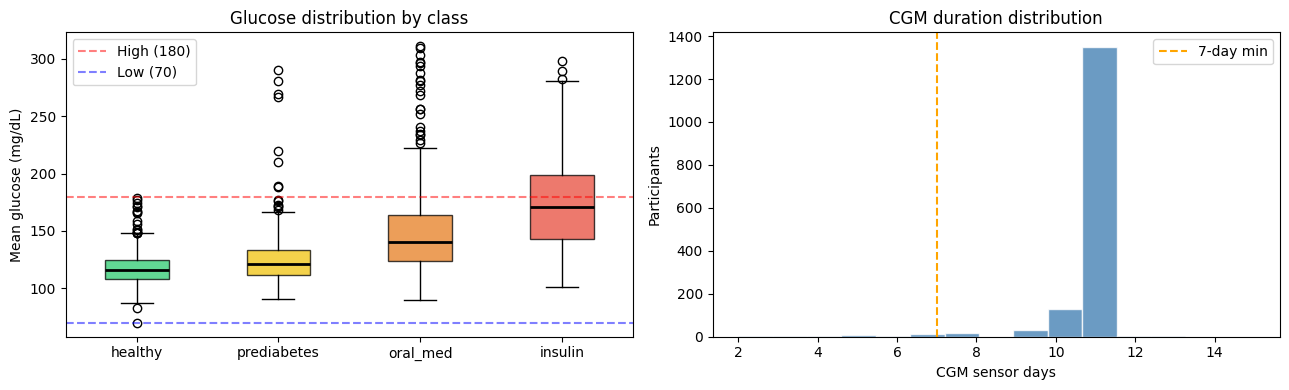

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

data_by_class = []
for c in range(4):
    idx = np.where(y == c)[0]
    avgs = [
        float(cgm_mdf[cgm_mdf.person_id == int(pids[i])].iloc[0]["average_glucose_level_mg_dl"])
        for i in idx if int(pids[i]) in cgm_pids
    ]
    data_by_class.append(avgs)

bp = axes[0].boxplot(data_by_class, labels=class_names_full, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], ["#2ecc71","#f1c40f","#e67e22","#e74c3c"]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].axhline(180, color="red",  linestyle="--", alpha=0.5, label="High (180)")
axes[0].axhline(70,  color="blue", linestyle="--", alpha=0.5, label="Low (70)")
axes[0].set_ylabel("Mean glucose (mg/dL)")
axes[0].set_title("Glucose distribution by class")
axes[0].legend()

axes[1].hist(cgm_days_arr, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(7, color="orange", linestyle="--", label="7-day min")
axes[1].set_xlabel("CGM sensor days"); axes[1].set_ylabel("Participants")
axes[1].set_title("CGM duration distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/figures/cgm_audit.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. CGM Feature Extraction

**8 clinically validated features per day:**

| Feature | Description |
|---|---|
| `glucose_mean` | Daily mean glucose (mg/dL) |
| `glucose_std` | Daily std — glycemic variability |
| `time_in_range` | % readings 70–180 mg/dL (gold standard) |
| `time_above_range` | % readings > 180 mg/dL (hyperglycemia burden) |
| `glucose_cv` | Coefficient of variation (std/mean × 100) |
| `nocturnal_mean` | Mean 12am–6am glucose (fasting proxy) |
| `mage` | Mean Amplitude of Glycemic Excursions |
| `peak_count` | Count of readings > 200 mg/dL |

**Quality gate:** ≥ 48 readings/day (4h coverage) required. Below threshold → NaN → masked from loss.


In [5]:
CGM_FEATURE_NAMES = [
    "glucose_mean", "glucose_std", "time_in_range",
    "time_above_range", "glucose_cv", "nocturnal_mean",
    "mage", "peak_count",
]
NUM_CGM = len(CGM_FEATURE_NAMES)   # 8
MIN_READINGS = 48                   # minimum per day

TIR_LO, TIR_HI = 70.0, 180.0
PEAK_THRESH     = 200.0


def _parse_val(v):
    if v in ("High", "HIGH"): return 400.0
    if v in ("Low",  "LOW"):  return 40.0
    if v in ("", None):       return None
    try:    return float(v)
    except: return None


def _mage(vals):
    """Mean Amplitude of Glycemic Excursions (proper algorithm)."""
    if len(vals) < 12:
        return np.nan
    v  = np.array(vals, dtype=float)
    sd = np.std(v)
    if sd == 0:
        return 0.0
    diffs = np.diff(v)
    signs = np.sign(diffs)
    # Find turning points
    tp = [0]
    for k in range(1, len(diffs)):
        if signs[k] != 0 and signs[k] != signs[tp[-1] if tp else 0]:
            tp.append(k)
    tp.append(len(v) - 1)
    tp_vals = v[tp]
    excursions = [abs(tp_vals[k+1] - tp_vals[k])
                  for k in range(len(tp_vals)-1)
                  if abs(tp_vals[k+1] - tp_vals[k]) >= sd]
    return float(np.mean(excursions)) if excursions else 0.0


def extract_daily_cgm(pid, cgm_path_map, existing_dates):
    fp_str = cgm_path_map.get(int(pid))
    if not fp_str:
        return {}
    fp = Path(fp_str)
    if not fp.exists():
        return {}
    with open(fp) as f:
        data = json.load(f)

    by_date      = defaultdict(list)
    by_date_hour = defaultdict(lambda: defaultdict(list))
    for r in data["body"]["cgm"]:
        val = _parse_val(r["blood_glucose"]["value"])
        if val is None:
            continue
        dt = datetime.fromisoformat(
            r["effective_time_frame"]["time_interval"]["start_date_time"]
            .replace("Z", "+00:00")
        )
        by_date[dt.date()].append(val)
        by_date_hour[dt.date()][dt.hour].append(val)

    result = {}
    for date in existing_dates:
        vals = by_date.get(date, [])
        if len(vals) < MIN_READINGS:
            result[date] = np.full(NUM_CGM, np.nan, dtype=np.float32)
            continue
        arr = np.array(vals, dtype=np.float32)
        gmean = float(np.mean(arr))
        gstd  = float(np.std(arr))
        tir   = float(np.mean((arr >= TIR_LO) & (arr <= TIR_HI)) * 100)
        tar   = float(np.mean(arr > TIR_HI) * 100)
        cv    = float(gstd / gmean * 100) if gmean > 0 else np.nan
        noc   = [v for h in range(0, 6) for v in by_date_hour[date].get(h, [])]
        noc_m = float(np.mean(noc)) if len(noc) >= 6 else gmean
        mage  = _mage(vals)
        peaks = float(np.sum(arr > PEAK_THRESH))
        result[date] = np.array([gmean, gstd, tir, tar, cv, noc_m, mage, peaks],
                                 dtype=np.float32)
    return result

print(f"CGM extraction functions ready. {NUM_CGM} features: {CGM_FEATURE_NAMES}")


CGM extraction functions ready. 8 features: ['glucose_mean', 'glucose_std', 'time_in_range', 'time_above_range', 'glucose_cv', 'nocturnal_mean', 'mage', 'peak_count']


## 3. Build CGM Feature Matrix

In [6]:
if CGM_PATH.exists() and CGM_MASK_PATH.exists():
    print("Loading cached CGM features...")
    X_cgm    = np.load(CGM_PATH)
    cgm_mask = np.load(CGM_MASK_PATH).astype(bool)
else:
    cgm_path_map = {
        int(row["person_id"]): str(DATASET_PATH) + str(row["glucose_filepath"])
        for _, row in cgm_mdf.iterrows()
        if not pd.isna(row["glucose_filepath"])
    }

    cohort     = build_cohort(exclude_dead_sensors=True)
    pid_to_row = {int(r["person_id"]): r for _, r in cohort.iterrows()}

    n, sl, _ = X_wear.shape
    X_cgm    = np.full((n, sl, NUM_CGM), np.nan, dtype=np.float32)
    cgm_mask = np.zeros((n, sl), dtype=bool)   # True = valid CGM for that day

    start = time.time(); errors = 0
    for i, pid in enumerate(pids):
        try:
            row = pid_to_row.get(int(pid))
            if row is None: continue
            cont   = extract_continuous_features(row)
            dates  = sorted(cont.keys())[:sl]
            if not dates: continue
            daily  = extract_daily_cgm(pid, cgm_path_map, dates)
            for d_idx, date in enumerate(dates):
                feats = daily.get(date, np.full(NUM_CGM, np.nan, dtype=np.float32))
                X_cgm[i, d_idx]    = feats
                cgm_mask[i, d_idx] = not np.any(np.isnan(feats))
        except Exception as e:
            errors += 1
            if errors <= 3: print(f"  ERROR PID {pid}: {e}")
        if (i+1) % 200 == 0:
            elapsed = time.time() - start
            print(f"  {i+1}/{n} | {elapsed:.0f}s | ETA {(n-i-1)/((i+1)/elapsed)/60:.1f}min")

    elapsed = time.time() - start
    print(f"\nDone in {elapsed:.0f}s. Errors: {errors}")
    print(f"Valid CGM days: {cgm_mask.sum()} / {cgm_mask.size} ({cgm_mask.mean()*100:.1f}%)")
    np.save(CGM_PATH, X_cgm); np.save(CGM_MASK_PATH, cgm_mask)
    print(f"Saved to {CGM_PATH}")

print(f"\nX_cgm shape : {X_cgm.shape}")
print(f"Valid days  : {cgm_mask.sum()} / {cgm_mask.size} ({cgm_mask.mean()*100:.1f}%)")


  200/1586 | 84s | ETA 9.7min


  400/1586 | 175s | ETA 8.6min


  600/1586 | 259s | ETA 7.1min


  800/1586 | 350s | ETA 5.7min


  1000/1586 | 426s | ETA 4.2min


  1200/1586 | 506s | ETA 2.7min


  1400/1586 | 589s | ETA 1.3min



Done in 669s. Errors: 0
Valid CGM days: 15193 / 22204 (68.4%)
Saved to outputs\features\X_cgm.npy

X_cgm shape : (1586, 14, 8)
Valid days  : 15193 / 22204 (68.4%)


In [7]:
print("CGM feature stats (on valid days):")
print(f"  {'Feature':20s}  {'Coverage':>9}  {'Mean':>8}  {'Std':>8}")
print("-" * 55)
for i, name in enumerate(CGM_FEATURE_NAMES):
    vals  = X_cgm[:,:,i][cgm_mask]
    valid = (~np.isnan(vals)).mean() * 100
    print(f"  {name:20s}  {valid:>8.1f}%  {np.nanmean(vals):>8.2f}  {np.nanstd(vals):>8.2f}")

print("\nClass-level CGM means (valid days):")
print(f"  {'Feature':20s}", end="")
for name in class_names_full: print(f"  {name:>12s}", end="")
print()
for i, feat in enumerate(CGM_FEATURE_NAMES):
    print(f"  {feat:20s}", end="")
    for c in range(4):
        idx  = np.where(y == c)[0]
        vals = X_cgm[idx,:,i][cgm_mask[idx]]
        print(f"  {np.nanmean(vals):>12.2f}", end="")
    print()


CGM feature stats (on valid days):
  Feature                Coverage      Mean       Std
-------------------------------------------------------
  glucose_mean             100.0%    135.52     41.19
  glucose_std              100.0%     24.14     12.61
  time_in_range            100.0%     87.02     22.65
  time_above_range         100.0%     12.09     22.50
  glucose_cv               100.0%     17.57      6.51
  nocturnal_mean           100.0%    141.12     46.84
  mage                     100.0%     47.38     24.12
  peak_count               100.0%     21.75     52.78

Class-level CGM means (valid days):
  Feature                    healthy   prediabetes      oral_med       insulin
  glucose_mean                117.52        126.14        150.13        181.16
  glucose_std                  18.90         21.09         27.99         39.34
  time_in_range                96.31         93.36         79.50         59.61
  time_above_range              2.50          5.92         19.86      

## 4. Multi-Task BiLSTM Architecture

```
Input (14, 41)  ← Original(22) + Option C(19) features per day
      │
      ▼
BiLSTM  hidden=128, 2 layers, dropout=0.4, bidirectional
output: (14, 256)  ← 256 because bidirectional doubles hidden size
      │
      ├── Attention pooling → context (256,)
      │         │
      │         ▼
      │   Classification head
      │   BN → Drop(0.4) → Linear(256,64) → ReLU → Drop(0.2) → Linear(64,4)
      │   Loss: CrossEntropyLoss (class-weighted + label_smoothing=0.1)
      │
      └── Per-step glucose head
          Linear(256, 8) applied to all 14 timestep outputs
          Loss: MaskedMSE — only on days with ≥48 CGM readings

Total loss: L = L_class + λ × L_glucose
```


In [8]:
class MultiTaskDiasense(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, drop=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden, layers,
            dropout=drop if layers > 1 else 0,
            batch_first=True, bidirectional=True,
        )
        out_dim = hidden * 2   # 256

        self.attn     = nn.Linear(out_dim, 1)
        self.cls_head = nn.Sequential(
            nn.BatchNorm1d(out_dim), nn.Dropout(drop),
            nn.Linear(out_dim, 64), nn.ReLU(),
            nn.Dropout(drop / 2),   nn.Linear(64, 4),
        )
        self.gluc_head = nn.Linear(out_dim, NUM_CGM)   # per-step

    def forward(self, x, lens=None):
        if lens is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lens.cpu(), batch_first=True, enforce_sorted=False)
            out, _ = self.lstm(packed)
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        else:
            out, _ = self.lstm(x)

        scores = self.attn(out).squeeze(-1)
        if lens is not None:
            mask = (torch.arange(out.size(1), device=out.device).unsqueeze(0)
                    >= lens.unsqueeze(1).to(out.device))
            scores = scores.masked_fill(mask, float("-inf"))
        w       = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = (out * w).sum(dim=1)

        return self.cls_head(context), self.gluc_head(out)   # (B,4), (B,14,8)


def masked_mse(pred, target, mask):
    """MSE only on (participant, day) pairs where mask=True."""
    mask_exp = mask.unsqueeze(-1).expand_as(pred)
    diff     = (pred - target) ** 2
    valid    = diff[mask_exp]
    return valid.mean() if valid.numel() > 0 else torch.tensor(0.0, device=pred.device)


# Quick shape sanity check
_m = MultiTaskDiasense(input_size=41).to(device)
_x = torch.randn(4, 14, 41).to(device)
_l = torch.tensor([14, 12, 10, 14])
_cls, _gluc = _m(_x, _l)
print(f"Classification logits : {tuple(_cls.shape)}  ✓")
print(f"Glucose predictions   : {tuple(_gluc.shape)}  ✓")
total_params = sum(p.numel() for p in _m.parameters())
print(f"Total parameters      : {total_params:,}")
del _m, _x, _l, _cls, _gluc


Classification logits : (4, 4)  ✓
Glucose predictions   : (4, 14, 8)  ✓
Total parameters      : 589,901


## 5. Training Pipeline

In [9]:
def run_multitask_cv(X_w, y, lengths, X_cgm, cgm_mask, lam=0.5, label="MT"):
    """5-fold stratified CV for the multi-task BiLSTM."""
    set_seed()
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_proba = np.zeros((len(y), 4))
    nf, sl    = X_w.shape[2], X_w.shape[1]

    print(f"\n[{label}]  λ={lam}  |  {N_FOLDS}-fold CV  |  wearable={sl}×{nf}  cgm={sl}×{NUM_CGM}")

    for fold, (tr, va) in enumerate(skf.split(X_w, y)):
        print(f"  Fold {fold+1}/{N_FOLDS}...", flush=True)
        ntr, nva = len(tr), len(va)

        # Impute + scale wearable
        Xtr_f = X_w[tr].reshape(-1, nf).copy()
        Xva_f = X_w[va].reshape(-1, nf).copy()
        imp_w = SimpleImputer(strategy="median")
        Xtr_f = imp_w.fit_transform(Xtr_f); Xva_f = imp_w.transform(Xva_f)
        sc_w  = StandardScaler()
        Xtr_f = sc_w.fit_transform(Xtr_f); Xva_f = sc_w.transform(Xva_f)

        # Impute + scale CGM (fit on train only)
        Ctr_f = X_cgm[tr].reshape(-1, NUM_CGM).copy()
        Cva_f = X_cgm[va].reshape(-1, NUM_CGM).copy()
        imp_c = SimpleImputer(strategy="median")
        Ctr_f = imp_c.fit_transform(Ctr_f); Cva_f = imp_c.transform(Cva_f)
        sc_c  = StandardScaler()
        Ctr_f = sc_c.fit_transform(Ctr_f); Cva_f = sc_c.transform(Cva_f)

        # Tensors
        Xt  = torch.tensor(Xtr_f.reshape(ntr, sl, nf).astype(np.float32))
        yt  = torch.tensor(y[tr],        dtype=torch.long)
        lt  = torch.tensor(lengths[tr],  dtype=torch.long)
        Ct  = torch.tensor(Ctr_f.reshape(ntr, sl, NUM_CGM).astype(np.float32))
        Mt  = torch.tensor(cgm_mask[tr], dtype=torch.bool)

        Xv  = torch.tensor(Xva_f.reshape(nva, sl, nf).astype(np.float32)).to(device)
        yv  = torch.tensor(y[va],        dtype=torch.long).to(device)
        lv  = torch.tensor(lengths[va],  dtype=torch.long)
        Cv  = torch.tensor(Cva_f.reshape(nva, sl, NUM_CGM).astype(np.float32)).to(device)
        Mv  = torch.tensor(cgm_mask[va], dtype=torch.bool).to(device)

        loader = DataLoader(TensorDataset(Xt, yt, lt, Ct, Mt), batch_size=64, shuffle=True)

        cc = np.bincount(y[tr], minlength=4).astype(float)
        cw = 1.0 / (cc + 1e-6); cw = cw / cw.sum() * 4
        wt = torch.tensor(cw, dtype=torch.float32).to(device)

        set_seed()
        model    = MultiTaskDiasense(input_size=nf).to(device)
        cls_loss = nn.CrossEntropyLoss(weight=wt, label_smoothing=0.1)
        opt      = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
        sched    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=7, factor=0.5)

        best_vl, pat, best_state = float("inf"), 0, None

        for ep in range(120):
            model.train()
            for Xb, yb, lb, Cb, Mb in loader:
                Xb = Xb.to(device); yb = yb.to(device)
                Cb = Cb.to(device); Mb = Mb.to(device)
                opt.zero_grad()
                cls_out, gluc_out = model(Xb, lb)
                l_cls   = cls_loss(cls_out, yb)
                l_gluc  = masked_mse(gluc_out, Cb, Mb) if lam > 0 else torch.tensor(0.0, device=device)
                (l_cls + lam * l_gluc).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            model.eval()
            with torch.no_grad():
                cv_out, _ = model(Xv, lv)
                vl = cls_loss(cv_out, yv).item()
            sched.step(vl)

            if vl < best_vl:
                best_vl = vl; pat = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                pat += 1
                if pat >= 20:
                    print(f"    Early stop ep {ep+1}", flush=True); break

        model.load_state_dict(best_state); model.eval()
        with torch.no_grad():
            cls_out, _ = model(Xv, lv)
            oof_proba[va] = torch.softmax(cls_out, dim=1).cpu().numpy()

    # Metrics
    pred  = np.argmax(oof_proba, axis=1)
    acc   = accuracy_score(y, pred)
    auc4  = roc_auc_score(y, oof_proba, multi_class="ovr", average="macro")
    y3    = np.array([LABEL_MAP_4_TO_3[i] for i in y])
    p3    = np.zeros((len(y), 3))
    p3[:,0] = oof_proba[:,0]; p3[:,1] = oof_proba[:,1]; p3[:,2] = oof_proba[:,2]+oof_proba[:,3]
    auc3  = roc_auc_score(y3, p3, multi_class="ovr", average="macro")
    y2    = np.array([LABEL_MAP_4_TO_2[i] for i in y])
    auc2  = roc_auc_score(y2, oof_proba[:,1]+oof_proba[:,2]+oof_proba[:,3])

    print(f"\n  Result [{label}]  acc={acc*100:.1f}%  4-AUC={auc4:.4f}  3-AUC={auc3:.4f}  2-AUC={auc2:.4f}")
    print(classification_report(y, pred, target_names=CLASS_NAMES_4, digits=3))

    safe_label = label.replace(".", "p")
    np.save(FEATURES_DIR / f"oof_{safe_label}.npy", oof_proba)
    return acc, auc4, auc3, auc2

print("Training function ready.")


Training function ready.


## 6. Lambda Sweep

λ=0.0 → classification only (BiLSTM baseline, same arch, no glucose supervision)
λ>0.0 → multi-task (glucose regression guides the encoder)


In [10]:
results = {}
for lam in [0.0, 0.3, 0.5, 1.0]:
    label = f"CGM_lam{str(lam).replace('.','p')}"
    acc, auc4, auc3, auc2 = run_multitask_cv(
        X_wear, y, lengths, X_cgm, cgm_mask, lam=lam, label=label
    )
    results[lam] = dict(acc=acc, auc4=auc4, auc3=auc3, auc2=auc2)
    print("=" * 60)

print("\nLambda sweep complete!")



[CGM_lam0p0]  λ=0.0  |  5-fold CV  |  wearable=14×41  cgm=14×8
  Fold 1/5...


    Early stop ep 25


  Fold 2/5...


    Early stop ep 23


  Fold 3/5...


...

  Fold 4/5...


    Early stop ep 23


  Fold 5/5...


    Early stop ep 23



  Result [CGM_lam1p0]  acc=35.7%  4-AUC=0.6637  3-AUC=0.6701  2-AUC=0.6682
              precision    recall  f1-score   support

     healthy      0.486     0.487     0.487       560
 prediabetes      0.322     0.266     0.291       410
    oral_med      0.376     0.170     0.235       446
     insulin      0.224     0.635     0.331       170

    accuracy                          0.357      1586
   macro avg      0.352     0.390     0.336      1586
weighted avg      0.384     0.357     0.348      1586


Lambda sweep complete!


## 7. Full Results Comparison

In [11]:
prev = {
    "Original LSTM (22feat)":  dict(acc=0.340, auc4=0.6618, auc3=None,   auc2=None),
    "+ Option C (41feat)":     dict(acc=0.339, auc4=0.6725, auc3=0.6706, auc2=0.6632),
    "+ Option C+D (51feat)":   dict(acc=0.351, auc4=0.6719, auc3=0.6738, auc2=0.6735),
    "Hourly 336-step":         dict(acc=0.311, auc4=0.6454, auc3=0.6508, auc2=0.6598),
}

print(f"{'Model':<30} {'Acc':>7} {'4-AUC':>7} {'3-AUC':>7} {'2-AUC':>7}")
print("-" * 62)
for name, r in prev.items():
    a3 = f"{r['auc3']:.4f}" if r['auc3'] else "  —   "
    a2 = f"{r['auc2']:.4f}" if r['auc2'] else "  —   "
    print(f"{name:<30} {r['acc']*100:>6.1f}% {r['auc4']:>7.4f} {a3:>7} {a2:>7}")

print()
print("CGM Multi-Task Results:")
print("-" * 62)
best_auc = max(r["auc4"] for r in results.values())
for lam, r in results.items():
    tag  = "  ← BEST" if r["auc4"] == best_auc else ""
    name = f"BiLSTM+CGM  λ={lam}"
    print(f"{name:<30} {r['acc']*100:>6.1f}% {r['auc4']:>7.4f} {r['auc3']:>7.4f} {r['auc2']:>7.4f}{tag}")

best_lam = max(results, key=lambda l: results[l]["auc4"])
print(f"\nBest λ={best_lam}  improvement over Option C: {results[best_lam]['auc4']-0.6725:+.4f}")


Model                              Acc   4-AUC   3-AUC   2-AUC
--------------------------------------------------------------
Original LSTM (22feat)           34.0%  0.6618    —       —   
+ Option C (41feat)              33.9%  0.6725  0.6706  0.6632
+ Option C+D (51feat)            35.1%  0.6719  0.6738  0.6735
Hourly 336-step                  31.1%  0.6454  0.6508  0.6598

CGM Multi-Task Results:
--------------------------------------------------------------
BiLSTM+CGM  λ=0.0                36.1%  0.6605  0.6663  0.6641
BiLSTM+CGM  λ=0.3                36.1%  0.6614  0.6696  0.6684
BiLSTM+CGM  λ=0.5                36.4%  0.6628  0.6694  0.6678
BiLSTM+CGM  λ=1.0                35.7%  0.6637  0.6701  0.6682  ← BEST

Best λ=1.0  improvement over Option C: -0.0088


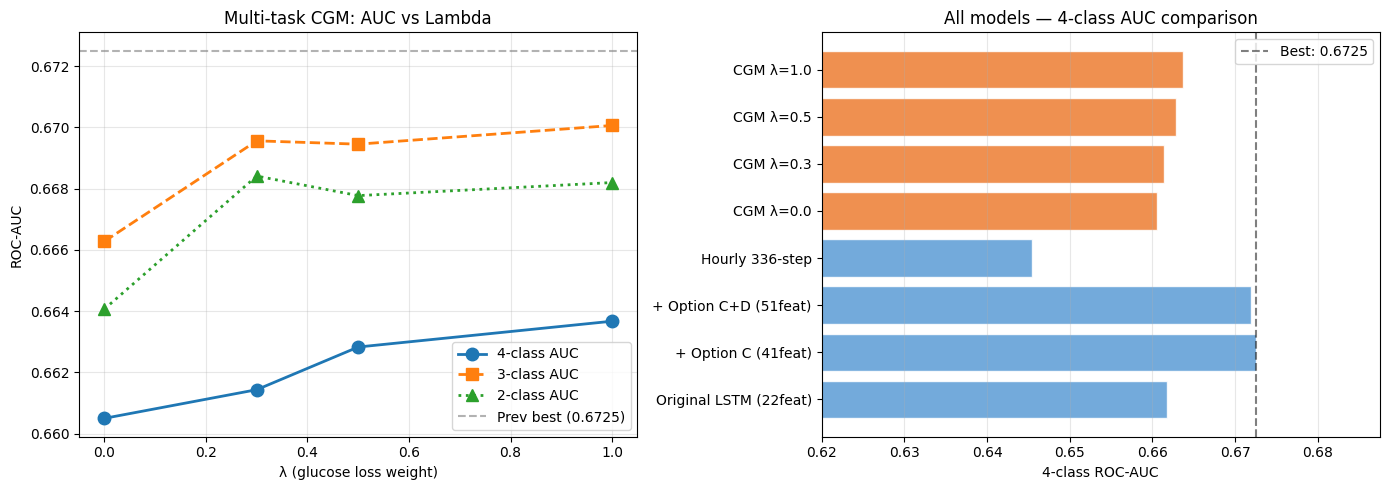

Saved: outputs/figures/cgm_multitask_results.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lam_vals  = list(results.keys())
auc4_vals = [results[l]["auc4"] for l in lam_vals]
auc3_vals = [results[l]["auc3"] for l in lam_vals]
auc2_vals = [results[l]["auc2"] for l in lam_vals]

axes[0].plot(lam_vals, auc4_vals, "o-",  label="4-class AUC", lw=2, ms=9)
axes[0].plot(lam_vals, auc3_vals, "s--", label="3-class AUC", lw=2, ms=9)
axes[0].plot(lam_vals, auc2_vals, "^:",  label="2-class AUC", lw=2, ms=9)
axes[0].axhline(0.6725, color="gray", linestyle="--", alpha=0.6, label="Prev best (0.6725)")
axes[0].set_xlabel("λ (glucose loss weight)")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Multi-task CGM: AUC vs Lambda")
axes[0].legend(); axes[0].grid(alpha=0.3)

all_names = list(prev.keys()) + [f"CGM λ={l}" for l in lam_vals]
all_auc4  = [prev[k]["auc4"] for k in prev] + auc4_vals
colors_b  = ["#5b9bd5"] * len(prev) + ["#ed7d31"] * len(lam_vals)
axes[1].barh(all_names, all_auc4, color=colors_b, alpha=0.85, edgecolor="white")
axes[1].axvline(max(all_auc4), color="black", linestyle="--", alpha=0.5,
                label=f"Best: {max(all_auc4):.4f}")
axes[1].set_xlabel("4-class ROC-AUC")
axes[1].set_title("All models — 4-class AUC comparison")
axes[1].set_xlim(0.62, max(all_auc4) + 0.015)
axes[1].legend(); axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/cgm_multitask_results.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/cgm_multitask_results.png")
